In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data=pd.read_excel("Car.xlsx")
data.head()

,CC/Batery_capasity_encoded,Hp_encoded,Speed_encoded,performance_encoded,cleaned_Car_prices,New Torque,Engine_displacement
0,3990.0,963.0,340,2.5,1100000.0,800.0,6.164987
1,6749.0,563.0,250,5.3,460000.0,900.0,6.164987
2,1200.0,77.5,165,10.5,13500.0,120.0,1.200000
3,3982.0,630.0,250,3.2,161000.0,900.0,6.164987
4,5204.0,602.0,320,3.6,253290.0,560.0,6.164987


In [3]:
data.columns

Index(['CC/Batery_capasity_encoded', 'Hp_encoded', 'Speed_encoded',
       'performance_encoded', 'cleaned_Car_prices', 'New Torque',
       'Engine_displacement'],
      dtype='object')

In [4]:
data.rename(columns={'CC/Batery_capasity_encoded':'BatteryCapasity','Hp_encoded':'HP','Speed_encoded':'speed','performance_encoded':'performance','cleaned_Car_prices':'Rate','New Torque':'Torque',"Engine_displacement":'Displacement'},inplace=True)

In [5]:
data.columns 

Index(['BatteryCapasity', 'HP', 'speed', 'performance', 'Rate', 'Torque',
       'Displacement'],
      dtype='object')

In [6]:
data.isnull().sum() 

BatteryCapasity    0
HP                 0
speed              0
performance        6
Rate               0
Torque             0
Displacement       0
dtype: int64

In [7]:
data["performance"].unique()

array([ 2.5 ,  5.3 , 10.5 ,  3.2 ,  3.6 ,  2.9 ,  4.  ,  3.4 ,  4.1 ,
        6.4 ,  5.6 ,  6.7 ,  6.9 ,  4.7 ,  7.3 ,  5.8 ,  8.2 ,  7.5 ,
        6.5 ,  6.8 ,  5.9 ,  3.9 ,  4.5 ,  4.2 ,  2.8 ,  3.  ,  3.1 ,
        3.3 ,  4.8 ,  4.4 ,  4.9 ,  5.2 ,  4.3 ,  5.1 ,  5.5 ,  5.7 ,
        6.1 ,  3.7 ,  3.5 ,  5.4 ,  6.3 ,  3.8 ,  8.5 , 10.3 , 10.9 ,
        8.4 ,  7.1 , 12.2 , 11.2 ,  8.9 ,  7.7 ,  7.2 ,  8.  ,  8.3 ,
        7.9 ,  8.1 ,  6.  ,  9.4 ,  9.5 ,  9.2 ,  6.2 , 10.2 ,  7.6 ,
       11.5 ,  9.  , 10.  ,   nan, 11.  , 14.8 , 13.5 ,  9.3 ,  7.4 ,
       14.  ,  9.8 ,  7.8 , 13.  ,  7.  ,  4.6 ,  8.8 , 14.3 , 12.9 ,
       10.8 , 23.  , 17.5 , 11.7 , 10.4 ,  8.6 , 12.4 ,  9.6 ,  9.9 ,
        8.7 , 12.  , 11.9 , 14.5 , 10.7 , 10.6 ,  6.6 , 10.1 , 13.7 ,
       12.5 ,  5.  , 15.  , 12.3 , 12.8 , 18.  , 18.5 , 13.8 ,  2.7 ,
        2.6 , 29.  , 16.  , 16.5 , 17.  , 17.6 ,  2.1 ,  1.9 ,  9.1 ,
        2.3 ,  2.4 ,  2.2 , 20.  , 22.  ,  6.3 ,  9.7 ,  5.75,  6.75,
        7.25, 15.5 ,

In [8]:
data["performance"].value_counts()

performance
6.50     47
7.50     45
8.50     40
10.50    39
8.00     35
         ..
6.30      1
6.75      1
7.25      1
35.00     1
7.05      1
Name: count, Length: 129, dtype: int64

In [9]:
data[data.isnull().any(axis=1)]

,BatteryCapasity,HP,speed,performance,Rate,Torque,Displacement
241,4009.000000,134.0,120,NaN,70000.000000,500.000000,4.000000
1096,3000.000000,150.0,120,NaN,40000.000000,370.000000,3.000000
1107,7500.000000,240.0,120,NaN,80000.000000,686.000000,7.500000
1108,3000.000000,150.0,120,NaN,55000.000000,370.000000,3.000000
1126,16.000000,64.0,100,NaN,19000.000000,196.000000,6.164987
1147,2767.179191,400.0,300,NaN,138036.952753,431.264435,6.164987


In [10]:
data["performance"]=data["performance"].fillna(data["performance"].mean())

In [11]:
data[data.isnull().any(axis=1)]

,BatteryCapasity,HP,speed,performance,Rate,Torque,Displacement


In [12]:
data.isnull().sum() 

BatteryCapasity    0
HP                 0
speed              0
performance        0
Rate               0
Torque             0
Displacement       0
dtype: int64

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   BatteryCapasity  1218 non-null   float64
 1   HP               1218 non-null   float64
 2   speed            1218 non-null   int64  
 3   performance      1218 non-null   float64
 4   Rate             1218 non-null   float64
 5   Torque           1218 non-null   float64
 6   Displacement     1218 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 66.7 KB


In [14]:
data.columns

Index(['BatteryCapasity', 'HP', 'speed', 'performance', 'Rate', 'Torque',
       'Displacement'],
      dtype='object')

In [15]:
from sklearn.model_selection import train_test_split


In [16]:
X=data.drop(columns=["performance","Rate","Displacement"],axis=1)
X

,BatteryCapasity,HP,speed,Torque
0,3990.0,963.0,340,800.0
1,6749.0,563.0,250,900.0
2,1200.0,77.5,165,120.0
3,3982.0,630.0,250,900.0
4,5204.0,602.0,320,560.0
...,...,...,...,...
1213,2487.0,240.0,180,239.0
1214,2393.0,326.0,180,630.0
1215,1987.0,182.5,190,200.0
1216,1798.0,169.0,180,197.5


In [17]:
y=data["Rate"]
y

0       1100000.0
1        460000.0
2         13500.0
3        161000.0
4        253290.0
          ...    
1213      45795.0
1214      50000.0
1215      27172.5
1216      33000.0
1217      36000.0
Name: Rate, Length: 1218, dtype: float64

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [19]:
X_train

,BatteryCapasity,HP,speed,Torque
461,4750.0,280.0,190,451.0
136,1984.0,248.0,240,500.0
1006,1598.0,180.0,200,250.0
433,87.0,389.0,200,600.0
3,3982.0,630.0,250,900.0
...,...,...,...,...
1044,2000.0,210.0,190,500.0
1095,2000.0,145.0,175,360.0
1130,2000.0,146.0,180,197.0
860,1591.0,120.0,180,151.0


In [20]:
X_train.corr()

,BatteryCapasity,HP,speed,Torque
BatteryCapasity,1.000000,0.586495,0.353934,0.732754
HP,0.586495,1.000000,0.693301,0.762841
speed,0.353934,0.693301,1.000000,0.492556
Torque,0.732754,0.762841,0.492556,1.000000


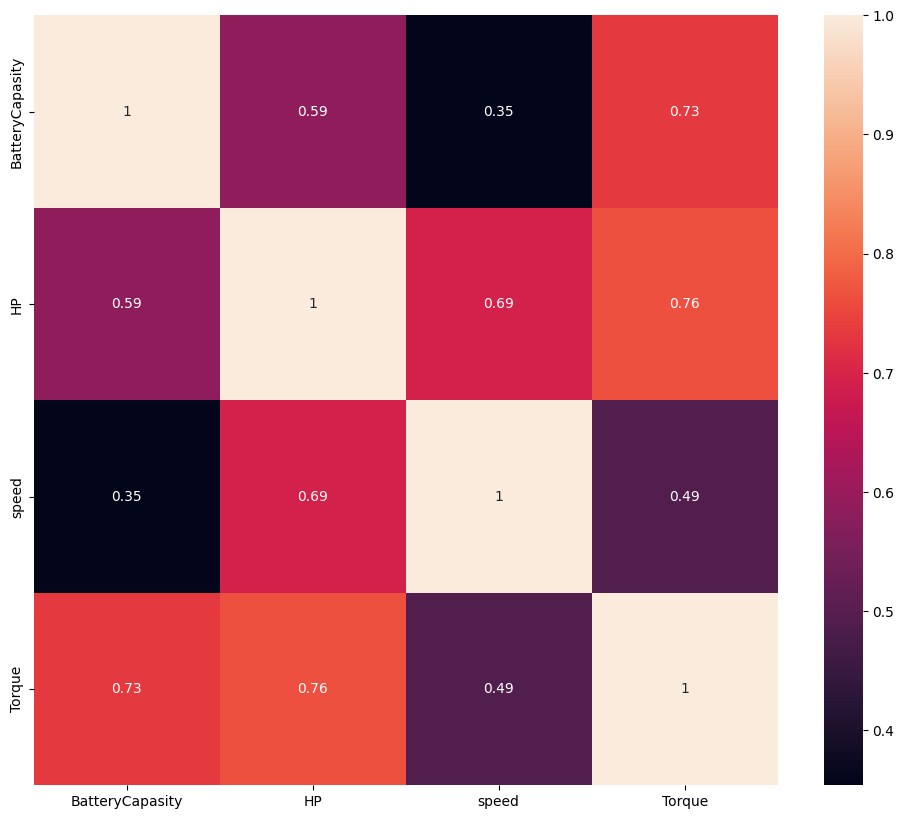

In [21]:
main_corr=X_train.corr()
plt.figure(figsize=(12,10))
sns.heatmap(main_corr,annot=True)
plt.show()

In [22]:
def find_weak_corr(data,threshold):
    col_core=set()
    corr_matrix=data.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])<threshold:
                colname=corr_matrix.columns[i]
                col_core.add(colname)
    return col_core

weak_corr=find_weak_corr(X_train,0.30)
weak_corr

set()

In [23]:
data.drop(weak_corr,axis=1,inplace=True)

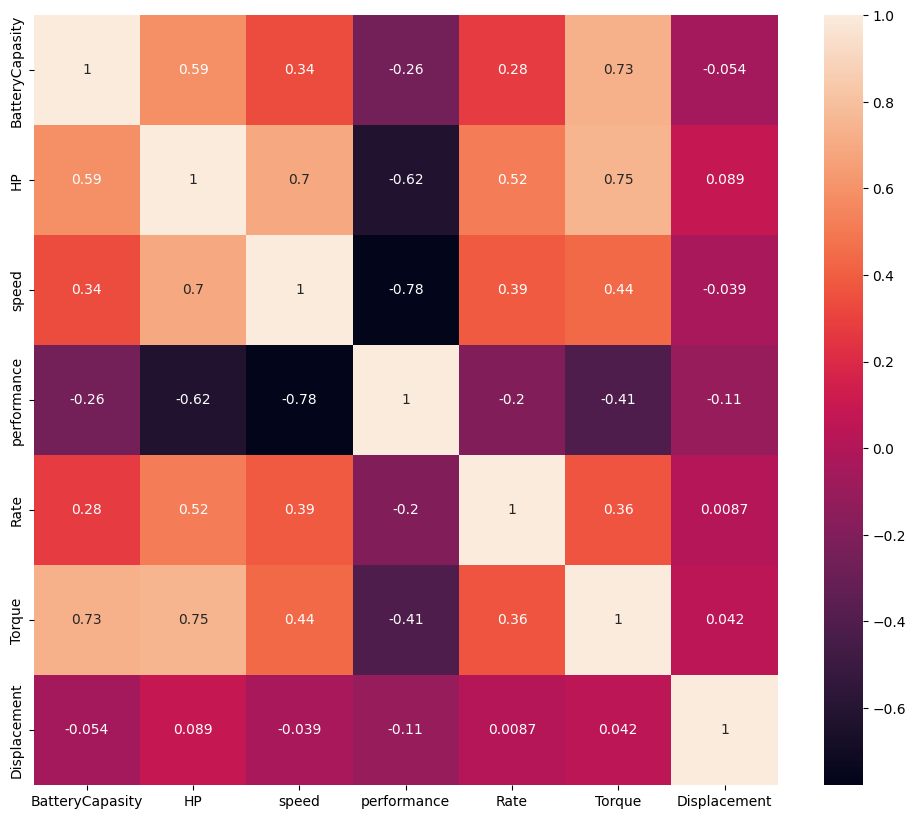

In [24]:
main_corr=data.corr()
plt.figure(figsize=(12,10))
sns.heatmap(main_corr,annot=True)
plt.show()

In [25]:
X_train

,BatteryCapasity,HP,speed,Torque
461,4750.0,280.0,190,451.0
136,1984.0,248.0,240,500.0
1006,1598.0,180.0,200,250.0
433,87.0,389.0,200,600.0
3,3982.0,630.0,250,900.0
...,...,...,...,...
1044,2000.0,210.0,190,500.0
1095,2000.0,145.0,175,360.0
1130,2000.0,146.0,180,197.0
860,1591.0,120.0,180,151.0


In [26]:
y_train

461      58000.0
136      45000.0
1006     38000.0
433      63000.0
3       161000.0
          ...   
1044     52000.0
1095     32500.0
1130     23000.0
860      17500.0
1126     19000.0
Name: Rate, Length: 913, dtype: float64

<Axes: >

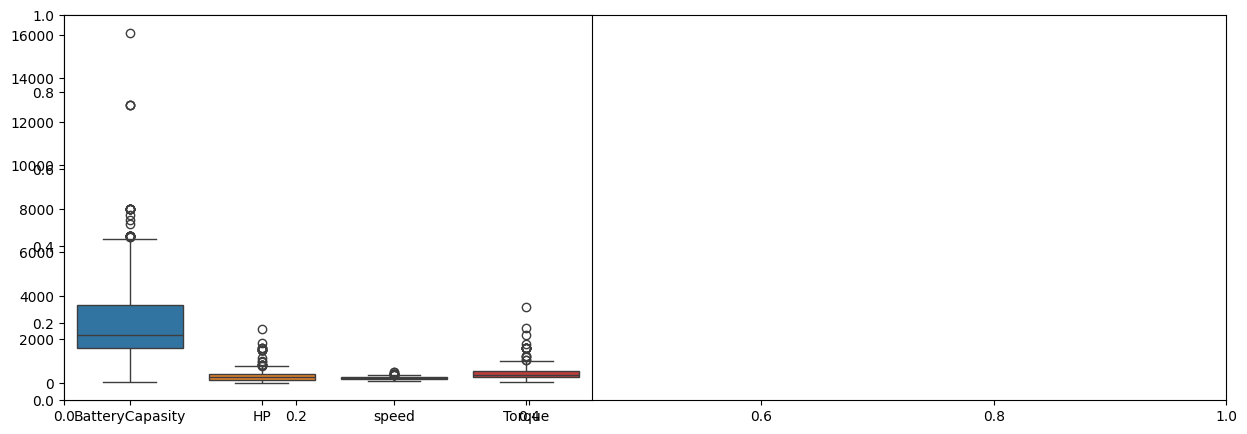

In [27]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

<Axes: >

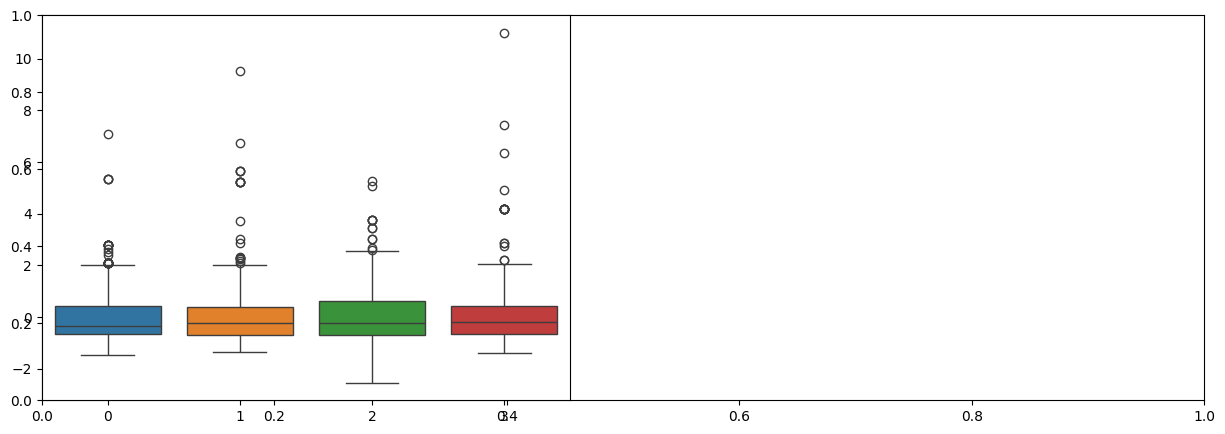

In [29]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train_scaled)

In [30]:
X_train_scaled

array([[ 1.04247601, -0.11766728, -0.50196268,  0.07371313],
       [-0.43287517, -0.25735998,  0.42597918,  0.24934736],
       [-0.63876294, -0.55420695, -0.31637431, -0.64674567],
       ...,
       [-0.42434097, -0.70263043, -0.68755105, -0.83671739],
       [-0.64249665, -0.81613075, -0.68755105, -1.0015985 ],
       [-1.48258274, -1.06059296, -2.17225802, -0.84030176]],
      shape=(913, 4))

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
lgr=LinearRegression()

In [32]:
lgr.fit(X_train_scaled,y_train)
y_pred=lgr.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2_score:",score)

MAE: 211758.61422292067
MSE: 70300247405.67368
RMSE: 265141.93822493206
R2_score: -0.6567324748793935


In [33]:
from sklearn.linear_model import Lasso
lassr=Lasso()
lassr.fit(X_train_scaled,y_train)
y_pred=lassr.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R2 Score:",score)

Mean Absolute Error: 211758.9123165906
Mean Squared Error: 70300390732.9051
Root Mean Squared Error: 265142.2085087644
R2 Score: -0.6567358526040479


In [34]:
#ridge regression
from sklearn.linear_model import Ridge
ridge=Ridge()

ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R2 Score:",score)

Mean Absolute Error: 211765.4476800685
Mean Squared Error: 70284183524.17282
Root Mean Squared Error: 265111.64350924466
R2 Score: -0.6563539050288283


In [35]:
#ellastic net regression
from sklearn.linear_model import ElasticNet
elastic=ElasticNet( )
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R2 Score:",score)

Mean Absolute Error: 187034.935284567
Mean Squared Error: 59074299692.0823
Root Mean Squared Error: 243052.05140480155
R2 Score: -0.39217590751653253
